In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/steam.csv', low_memory=False)
print("Dimensões:", df.shape)
df.head(5)

Dimensões: (27075, 18)


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [3]:
df.info()
print(df.isnull().sum().sort_values(ascending=False).head(15))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [4]:
cols = [
    'name', 'release_date', 'english', 'developer', 'publisher',
    'platforms', 'required_age', 'categories', 'genres',
    'positive_ratings', 'negative_ratings', 'average_playtime',
    'owners', 'price'
]
df = df[cols]

In [5]:
df = df[df['price'] > 0]

In [6]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [7]:
df['release_year'] = df['release_date'].dt.year

In [8]:
df = df[df['price'] < 200]

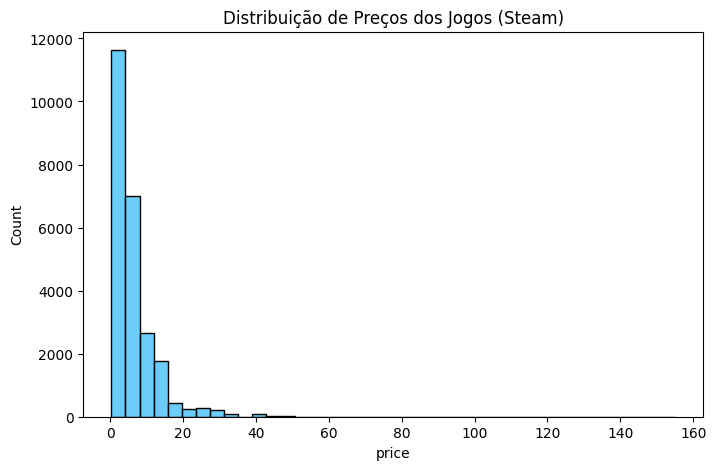

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40, color="#38BDF8")
plt.title("Distribuição de Preços dos Jogos (Steam)")
plt.show()

In [12]:
df.to_csv('../data/steam_clean.csv', index=False)
print("Dataset limpo salvo em data/steam_clean.csv")

Dataset limpo salvo em data/steam_clean.csv


In [13]:
df.shape

(24512, 15)

In [15]:
print(df.head(10))

                             name release_date  english         developer  \
0                  Counter-Strike   2000-11-01        1             Valve   
1           Team Fortress Classic   1999-04-01        1             Valve   
2                   Day of Defeat   2003-05-01        1             Valve   
3              Deathmatch Classic   2001-06-01        1             Valve   
4       Half-Life: Opposing Force   1999-11-01        1  Gearbox Software   
5                        Ricochet   2000-11-01        1             Valve   
6                       Half-Life   1998-11-08        1             Valve   
7  Counter-Strike: Condition Zero   2004-03-01        1             Valve   
8           Half-Life: Blue Shift   2001-06-01        1  Gearbox Software   
9                     Half-Life 2   2004-11-16        1             Valve   

  publisher          platforms  required_age  \
0     Valve  windows;mac;linux             0   
1     Valve  windows;mac;linux             0   
2     Va